In [5]:
import math,numpy as np,torch
from torch import nn
from d2l import torch as d2l

In [6]:
max_degree = 20  # 多项式最大阶数
n_train,n_test = 100,100
true_w = np.zeros((max_degree))  # 分配最大空间
true_w

array([0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0.])

In [7]:
true_w[:4] = np.array([5,1.2,-3.4,5.6])  # 分配前四项
features = np.random.normal(size=(n_train + n_test, 1))  # 200个样本一个特征

poly_features = np.power(features,np.arange(max_degree).reshape(1,-1))  # 一行多列 广播机制
for i in range(max_degree):
    poly_features[:,i] /= math.gamma(i+1)  # gamma(n) = (n-1)!

labels = np.dot(poly_features,true_w)
labels += np.random.normal(scale=0.01,size=labels.shape)  # 加噪

In [8]:
# numpy 转换成 tensor
true_w, features, poly_features, labels = [torch.tensor(x, dtype=torch.float32) for x in [true_w,features,poly_features,labels]]

In [9]:
features[:2],poly_features[:2,:],labels[:2]

(tensor([[-1.5008],
         [ 1.5134]]),
 tensor([[ 1.0000e+00, -1.5008e+00,  1.1262e+00, -5.6339e-01,  2.1138e-01,
          -6.3449e-02,  1.5871e-02, -3.4026e-03,  6.3833e-04, -1.0645e-04,
           1.5975e-05, -2.1796e-06,  2.7259e-07, -3.1470e-08,  3.3735e-09,
          -3.3753e-10,  3.1660e-11, -2.7950e-12,  2.3304e-13, -1.8408e-14],
         [ 1.0000e+00,  1.5134e+00,  1.1452e+00,  5.7768e-01,  2.1856e-01,
           6.6153e-02,  1.6686e-02,  3.6074e-03,  6.8242e-04,  1.1475e-04,
           1.7366e-05,  2.3892e-06,  3.0132e-07,  3.5077e-08,  3.7918e-09,
           3.8256e-10,  3.6185e-11,  3.2212e-12,  2.7083e-13,  2.1572e-14]]),
 tensor([-3.7966,  6.1611]))

In [10]:
# 定义损失函数
def evaluate_loss(net,data_iter,loss):
    metric = d2l.Accumulator(2)  # 为什么是2来着
    for x,y in data_iter:
        out = net(x)
        y = y.reshape(out.shape)
        l = loss(out,y)
        metric.add(l.sum(),l.numel())  # 总和和样本个数
    return metric[0] / metric[1]

In [23]:
# 定义训练函数
def train(train_features,test_features,train_labels,test_labels,num_epochs=400):
    loss = nn.MSELoss()
    input_shape = train_features.shape[-1]
    net = nn.Sequential(nn.Linear(input_shape,1,bias=False))
    batch_size = min(10,train_labels.shape[0])
    train_iter = d2l.load_array((train_features,train_labels.reshape(-1,1)),batch_size)
    test_iter = d2l.load_array((test_features,test_labels),batch_size,is_train=False)
    trainer = torch.optim.SGD(net.parameters(),lr=0.01)
    animator = d2l.Animator(xlabel='epoch',ylabel='loss',yscale='log',xlim=[1,num_epochs],ylim=[1e-5,1e2],legend=['train','test'])
    for epoch in range(num_epochs):
        d2l.train_epoch_ch3(net,train_iter,loss,trainer)
        if epoch == 0 or (epoch+1) % 20 == 0:
            animator.add(epoch+1,(evaluate_loss(net,train_iter,loss),evaluate_loss(net,test_iter,loss)))
    print('weight:',net[0].weight.data.numpy())

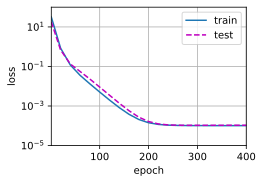

In [24]:
train(poly_features[:n_train,:4],poly_features[n_train:,:4],labels[:n_train],labels[n_train:])

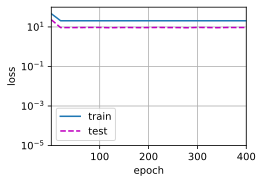

In [25]:
train(poly_features[:n_train,:2],poly_features[n_train:,:2],labels[:n_train],labels[n_train:])

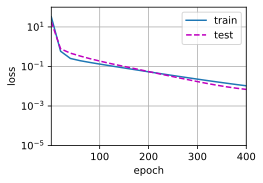

In [26]:
train(poly_features[:n_train,:],poly_features[n_train:,:],labels[:n_train],labels[n_train:])